# K06_00_Entscheidungsbaum_Iris_Grundlagen

Dozentenversion vom 23. Mai 2026

# Trainieren eines Entscheidungsbaums

In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
# iris als pandas Dataframe laden
iris = load_iris(as_frame=True)
X_iris_petal = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris_petal, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=42)

# Visualisieren eines Entscheidungsbaums für Kronblätter

[Text(0.4, 0.8333333333333334, 'petal length (cm) <= 2.45\ngini = 0.667\nsamples = 150\nvalue = [50, 50, 50]\nclass = setosa'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 50\nvalue = [50, 0, 0]\nclass = setosa'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'petal width (cm) <= 1.75\ngini = 0.5\nsamples = 100\nvalue = [0, 50, 50]\nclass = versicolor'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.168\nsamples = 54\nvalue = [0, 49, 5]\nclass = versicolor'),
 Text(0.8, 0.16666666666666666, 'gini = 0.043\nsamples = 46\nvalue = [0, 1, 45]\nclass = virginica')]

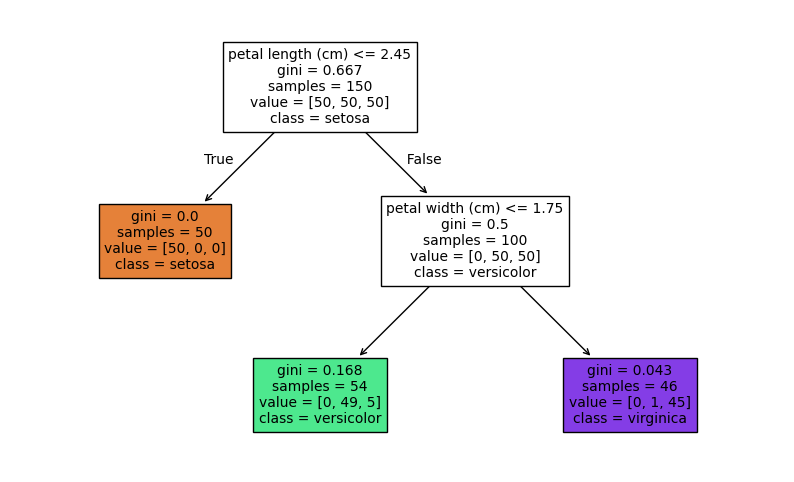

In [3]:
# den Entscheidungsbaum ausdrucken.
plt.figure(figsize= (10,6))
tree.plot_tree(tree_clf, filled = True, fontsize=10,
               feature_names=["petal length (cm)", "petal width (cm)"],
               class_names = iris.target_names)

# Visualisieren der Entscheidungsgrenzen

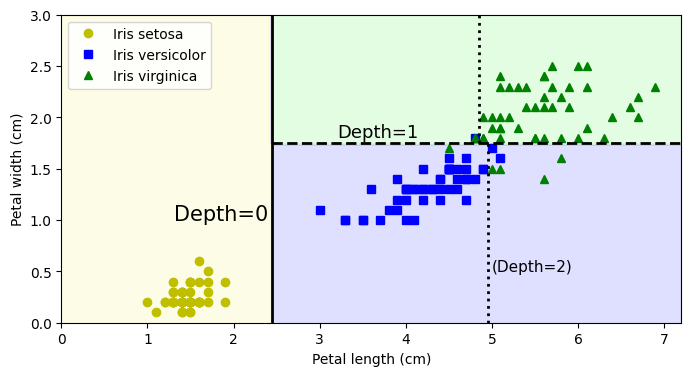

In [4]:
# extra code – just formatting details

custom_cmap = ListedColormap(['#fafab0', '#9898ff', '#a0faa0'])
plt.figure(figsize=(8, 4))

lengths, widths = np.meshgrid(np.linspace(0, 7.2, 100), np.linspace(0, 3, 100))
X_iris_all = np.c_[lengths.ravel(), widths.ravel()]
y_pred = tree_clf.predict(X_iris_all).reshape(lengths.shape)
plt.contourf(lengths, widths, y_pred, alpha=0.3, cmap=custom_cmap)
for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
    plt.plot(X_iris_petal[:, 0][y_iris == idx], X_iris_petal[:, 1][y_iris == idx],
             style, label=f"Iris {name}")


# Entscheidungsgrenzen drucken
tree_clf_deeper = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf_deeper.fit(X_iris_petal, y_iris)
th0, th1, th2a, th2b = tree_clf_deeper.tree_.threshold[[0, 2, 3, 6]]
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.plot([th0, th0], [0, 3], "k-", linewidth=2)
plt.plot([th0, 7.2], [th1, th1], "k--", linewidth=2)
plt.plot([th2a, th2a], [0, th1], "k:", linewidth=2)
plt.plot([th2b, th2b], [th1, 3], "k:", linewidth=2)
plt.text(th0 - 0.05, 1.0, "Depth=0", horizontalalignment="right", fontsize=15)
plt.text(3.2, th1 + 0.02, "Depth=1", verticalalignment="bottom", fontsize=13)
plt.text(th2a + 0.05, 0.5, "(Depth=2)", fontsize=11)
plt.axis([0, 7.2, 0, 3])
plt.legend()
# save_fig("decision_tree_decision_boundaries_plot")

plt.show()

# Schätzen von Wahrscheinlichkeiten für Kategorien

In [5]:
# Nehmen wir an, wir hätten eine Blüte mit 5 cm langen und 1,5 cm breiten
# Kronblättern entdeckt.

probabilities = tree_clf.predict_proba([[5, 1.5]])[0]

# Der dazu passende Knoten im Baum ist der Knoten bei depth 2 auf der linken Seite.
# Daher gibt der Entscheidungsbaum folgende Wahrscheinlichkeiten aus:
for name, prob in zip(iris.target_names, probabilities):
    print(f"{name}: {prob:.1%}")

# im Klartext ausgeben
predicted_class_index = tree_clf.predict([[5, 1.5]])[0]
predicted_class_name = iris.target_names[predicted_class_index]
print(f"Die vorhergesagte Klasse ist: {predicted_class_name}")

setosa: 0.0%
versicolor: 90.7%
virginica: 9.3%
Die vorhergesagte Klasse ist: versicolor


## Erweiterung: Entscheidungsbaum mit allen 4 Merkmalen

Bisher haben wir nur **2 Merkmale** verwendet (`petal length` und `petal width`),
um den Baum gut visualisieren zu können.

Jetzt trainieren wir einen Baum auf **allen 4 Merkmalen** des Iris-Datensatzes:

| Index | Merkmal |
|:---:|---|
| 0 | sepal length (cm) |
| 1 | sepal width (cm) |
| 2 | petal length (cm) |
| 3 | petal width (cm) |

Leitfrage: **Welche Merkmale sind für die Klassifikation wirklich wichtig?**


In [6]:
# Alle 4 Merkmale verwenden
X_all = iris.data.values          # Shape: (150, 4)
y_all = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

tree_all = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_all.fit(X_train, y_train)

acc = accuracy_score(y_test, tree_all.predict(X_test))
print(f"Accuracy auf dem Testset: {acc:.3f}")
print(f"Anzahl Merkmale: {X_all.shape[1]}")


Accuracy auf dem Testset: 0.967
Anzahl Merkmale: 4


## Feature Importance

Ein Entscheidungsbaum berechnet für jedes Merkmal, wie stark es zur
Verbesserung der Knotenreinheit beiträgt. Dieser Wert heißt **Feature Importance**.

- Werte liegen zwischen **0 und 1**
- Die Summe aller Importances ergibt **1**
- Ein hoher Wert bedeutet: dieses Merkmal trägt stark zur Klassifikation bei

> **Merksatz:** Feature Importance beantwortet die Frage:
> *"Feature Importance zeigt, welche Merkmale für die Entscheidungen des Modells besonders wichtig sind."*


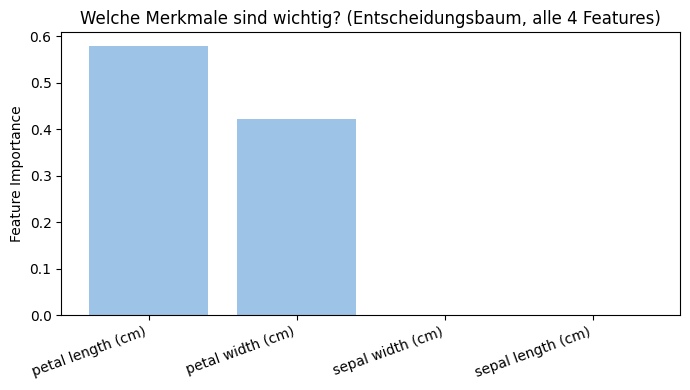


Feature Importance im Detail:
  petal length (cm)        : 0.579
  petal width (cm)         : 0.421
  sepal width (cm)         : 0.000
  sepal length (cm)        : 0.000


In [7]:
importances = tree_all.feature_importances_   # ein Wert pro Merkmal
feature_names = iris.feature_names

# Absteigend sortieren
indices = np.argsort(importances)[::-1]

# Barplot
plt.figure(figsize=(7, 4))
plt.bar(
    range(len(importances)),
    importances[indices],
    color=["#2E75B6" if i == indices[0] else "#9DC3E6" for i in range(len(importances))]
)
plt.xticks(
    range(len(importances)),
    [feature_names[i] for i in indices],
    rotation=20, ha="right"
)
plt.ylabel("Feature Importance")
plt.title("Welche Merkmale sind wichtig? (Entscheidungsbaum, alle 4 Features)")
plt.tight_layout()
plt.show()

# Zahlenwerte ausgeben
print("\nFeature Importance im Detail:")
for i in indices:
    print(f"  {feature_names[i]:25s}: {importances[i]:.3f}")


### Interpretation

Der Barplot zeigt: **nicht alle Merkmale sind gleich wichtig**.

Typisches Ergebnis auf dem Iris-Datensatz:
- `petal length` und `petal width` erklären den Großteil der Klassifikation
- `sepal length` trägt wenig bei
- `sepal width` trägt kaum etwas bei

Das deckt sich mit unserem ersten Baum (nur Kronblattmerkmale): der Baum hatte
diese Merkmale intuitiv bevorzugt – Feature Importance macht das **messbar**.
